# Exploratory Data Analysis (EDA) on Titanic Dataset


## Introduction

The Titanic dataset is one of the most popular datasets used for data analysis and machine learning. It contains information about passengers such as age, gender, ticket class, fare, and survival status.

The objective of this project is to perform Exploratory Data Analysis (EDA) to understand the data, identify patterns, handle missing values, detect outliers, and extract meaningful insights that can help in predicting survival.


## Objective

* To understand the structure and distribution of the dataset
* To analyze the relationship between different features and survival
* To handle missing values and detect outliers
* To visualize important patterns using graphs
* To derive meaningful insights from the data


In [1]:
## Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
## Loading the Dataset

train = pd.read_csv('../data/titanic_train.csv')
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Overview

In [4]:
train.info()   # Tells what are the Datatypes of all the attributes that dataset contains

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.shape         # Tells the dimensions of the Titanic dataset

(891, 12)

## Missing Values Analysis

In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- That means the Age and Cabin has major null values and embarked has 2
- The Cabin has many null values (687 out of 891) that make this column redundant of our work so we can drop it

<Axes: >

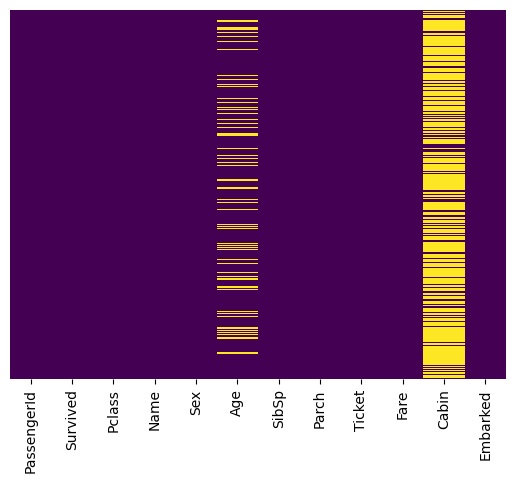

In [8]:
# we can visualize by heatmap

sns.heatmap(train.isnull() , yticklabels=False , cbar = False , cmap = 'viridis')

- To handle the missing value of Age we have to see what is average age in each class so that we can replacce null with average value

<Axes: xlabel='Pclass', ylabel='Age'>

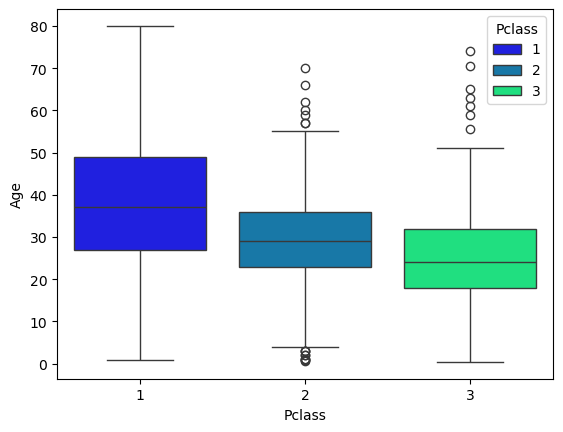

In [9]:
sns.boxplot(x='Pclass' , y='Age' , data = train,hue='Pclass', palette='winter')

- From boxplot we can see that Class 1 has average age 37, Class 2 has average age 29, Class 3 has average age 24

In [10]:
def fill_age(cols):
    age = cols['Age']
    pclass = cols['Pclass']

    if pd.isnull(age):
        if pclass == 1:
            return 37
        elif pclass == 2:
            return 29
        elif pclass == 3:
            return 24
    else:
        return age


<Axes: >

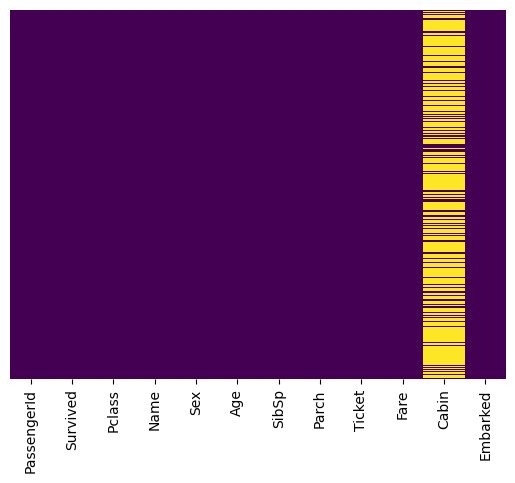

In [11]:
## Replacing Null values with average value of that Class

train['Age'] = train[['Age' , 'Pclass']].apply(fill_age , axis=1)

sns.heatmap(train.isnull() , yticklabels=False , cbar = False , cmap = 'viridis')

In [12]:
# Dropping the Cabin column as it is irrelevent

train.drop('Cabin' , axis = 1,inplace=True)

In [13]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

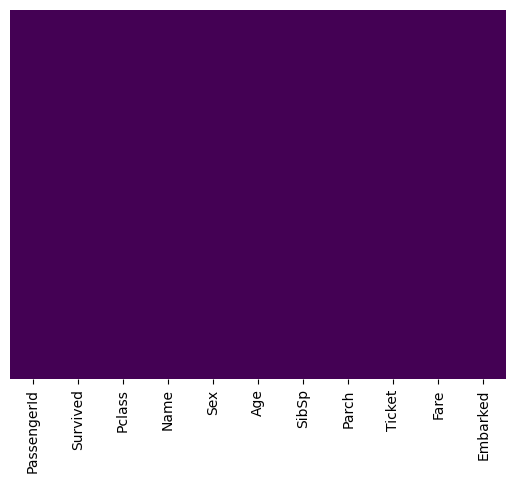

In [14]:
sns.heatmap(train.isnull() , yticklabels=False , cbar = False , cmap = 'viridis')

## Univariate Analysis

### Distribution of Age

<Axes: xlabel='Age', ylabel='Count'>

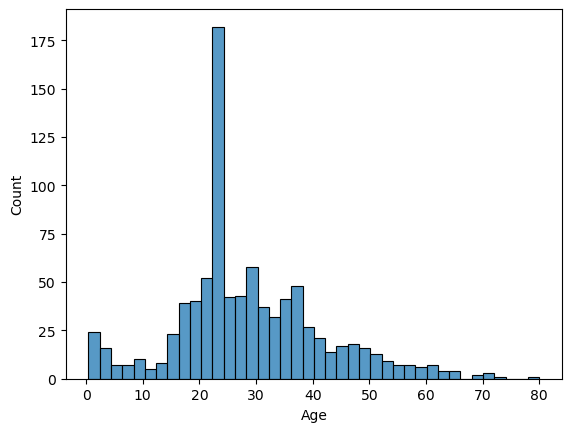

In [15]:
sns.histplot(data = train , x = 'Age' , bins=40)

#### Tells that the majority of people in Titanic were from age 20 to 35

### Distribution of Fare

<Axes: xlabel='Fare', ylabel='Count'>

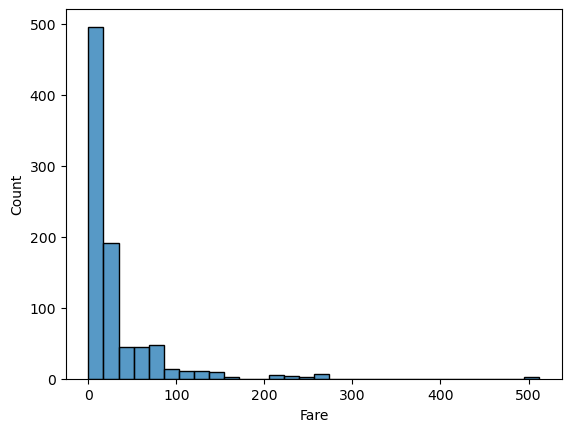

In [16]:
sns.histplot(data = train , x = 'Fare' , bins=30)

#### It shows that Most ticket fares fall within the range of 0–20 dollars

### Count of passengers by Gender

577
314


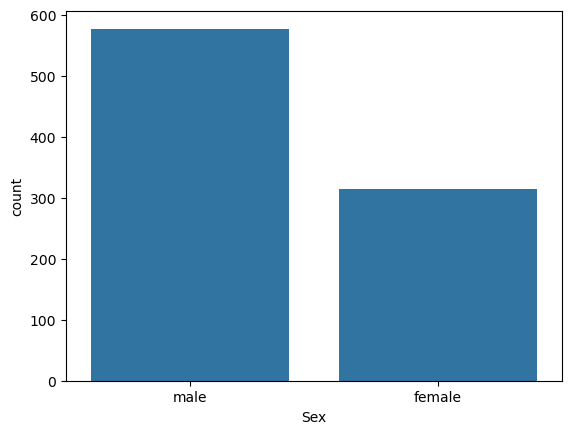

In [17]:
sns.countplot(data = train , x = 'Sex')
print(train['Sex'].value_counts()['male'])
print(train['Sex'].value_counts()['female'])

#### It shows that male passengers were more than female passengers male = 577 and female = 314

### Count of passengers by Survival

549
342


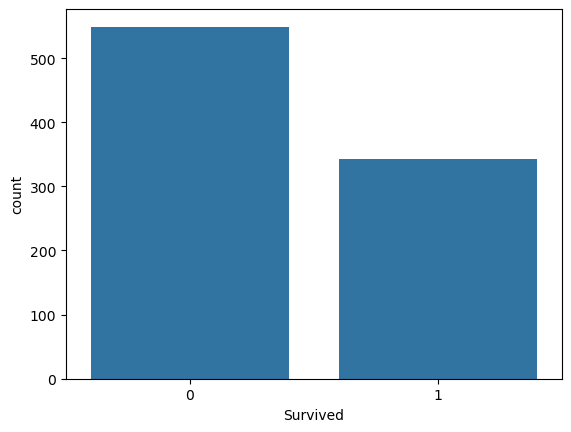

In [18]:
sns.countplot(data = train , x = 'Survived')
print(train['Survived'].value_counts()[0])
print(train['Survived'].value_counts()[1])

#### It tells that in tragic accidents 549 passengers can not survived whereas luckily 342 passengers survived

## Bivariate Analysis

### Survival vs Gender

468
109
81
233


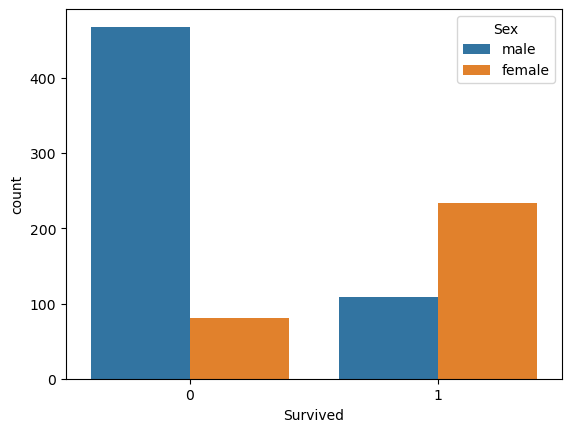

In [19]:
sns.countplot(data = train , x = 'Survived' , hue='Sex')
print(train[['Survived','Sex']].value_counts()[(0,'male')])
print(train[['Survived','Sex']].value_counts()[(1,'male')])

print(train[['Survived','Sex']].value_counts()[(0,'female')])
print(train[['Survived','Sex']].value_counts()[(1,'female')])

#### The countplot and value counts reveal a stark contrast in survival rates based on gender. While men made up the majority of the passengers, they suffered the most casualties (468 dead vs. 109 survived). Women, despite being fewer in number, were highly prioritized during the rescue, with nearly three times as many surviving (233) as dying (81).

### Survival vs Passenger Class

80
97
372
136
87
119


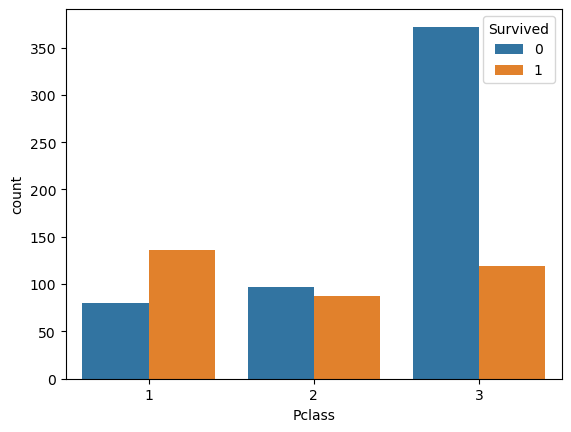

In [20]:
sns.countplot(data = train , x = 'Pclass' , hue='Survived')
print(train[['Survived','Pclass']].value_counts()[(0,1)])
print(train[['Survived','Pclass']].value_counts()[(0,2)])
print(train[['Survived','Pclass']].value_counts()[(0,3)])

print(train[['Survived','Pclass']].value_counts()[(1,1)])
print(train[['Survived','Pclass']].value_counts()[(1,2)])
print(train[['Survived','Pclass']].value_counts()[(1,3)])

#### The countplot and grouped data reveal a stark class divide in survival rates. First-class passengers were the only group where survivors (136) outnumbered casualties (80). As ticket class decreases, the survival rate drops significantly. Third-class passengers made up the largest group on the ship but experienced the worst outcomes, with more than three times as many casualties (372) as survivors (119).

### Fare vs Survival

<Axes: xlabel='Survived', ylabel='Fare'>

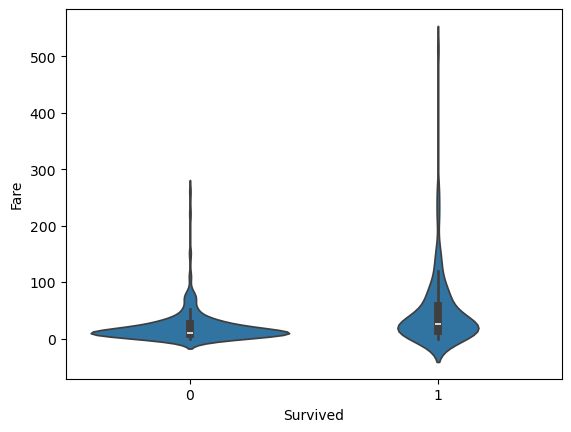

In [21]:
sns.violinplot(data = train,y='Fare' , x='Survived')

<Axes: xlabel='Survived', ylabel='Fare'>

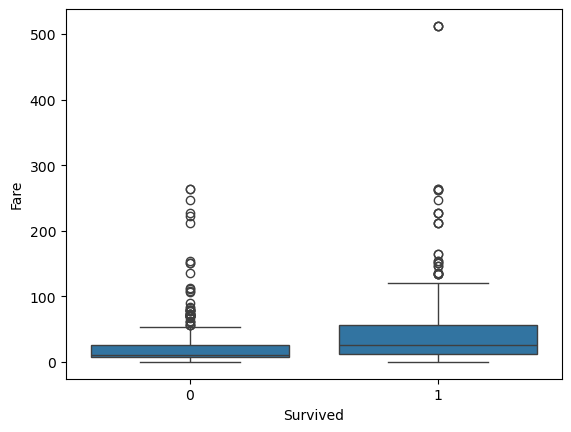

In [22]:
sns.boxplot(x='Survived', y='Fare', data=train)

### countplot of embarkation with survival as hue

<Axes: xlabel='Embarked', ylabel='count'>

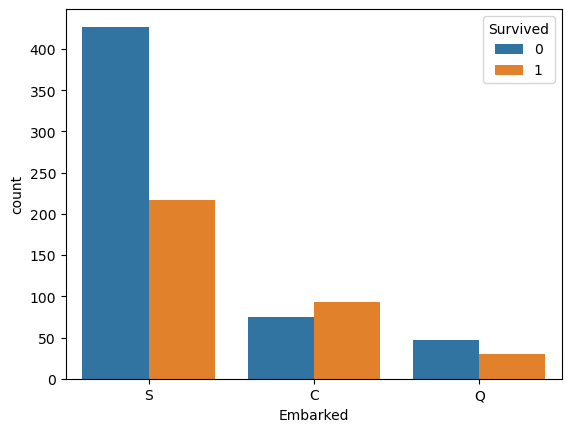

In [23]:
sns.countplot(data = train , x = 'Embarked' , hue = "Survived")

#### The countplot shows that a passenger's port of embarkation is linked to their likelihood of survival. The majority of the ship boarded at Southampton (S) and suffered the heaviest total losses. In contrast, passengers who boarded at Cherbourg (C) fared much better, being the only group where survivors (93) outnumbered casualties (75). This discrepancy hints that embarkation ports may be tied to other survival factors, such as the proportion of 1st-class vs. 3rd-class tickets sold at each location.

### scatterplot to visualize age vs fare

<Axes: xlabel='Age', ylabel='Fare'>

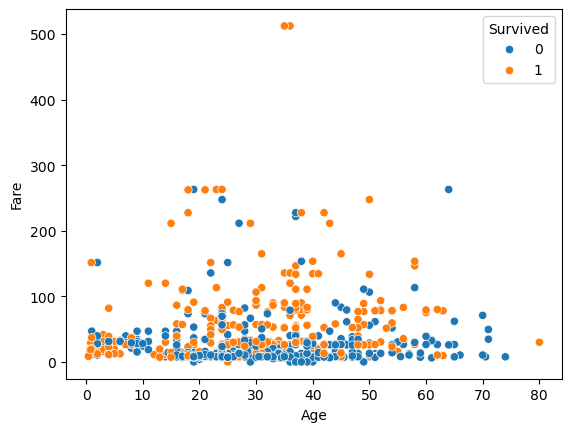

In [24]:
sns.scatterplot(data = train , x = 'Age' ,y='Fare' , hue='Survived')

## Correlation Heatmap

<Axes: >

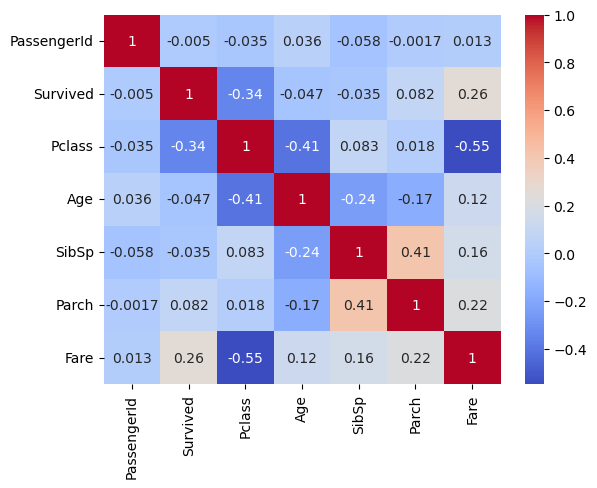

In [25]:
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')

### correlation heatmap of numerical features with Survival

<Axes: >

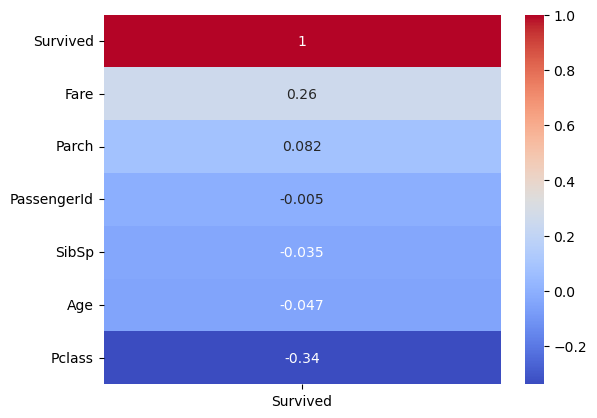

In [26]:
sns.heatmap(train.corr(numeric_only=True)[['Survived']].sort_values(by='Survived', ascending=False),annot=True,cmap='coolwarm')

#### This sorted heatmap clearly ranks the numerical predictors of survival. Socioeconomic status dominates the outcomes: Fare is the strongest positive predictor, while Pclass is the strongest negative predictor (meaning lower-numbered classes survived more). Conversely, demographic variables like Age, SibSp, and Parch show correlation coefficients very close to zero, indicating they were statistically much less influential in determining a passenger's survival.

## FacetGrid to analyze age distribution across different classes and survival status.

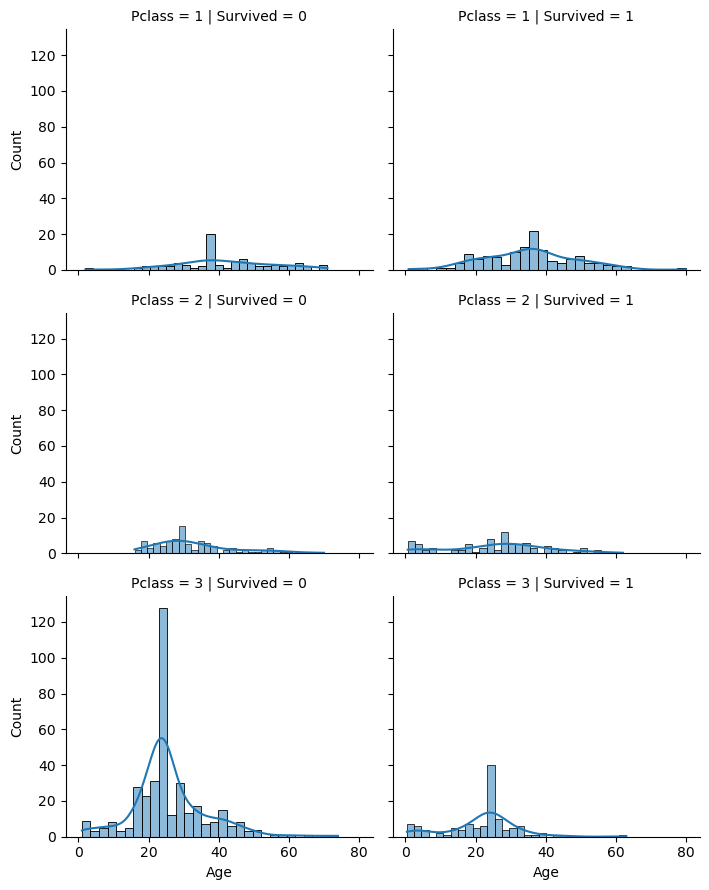

In [27]:
g = sns.FacetGrid(data=train, row='Pclass', col='Survived', height=3, aspect=1.2)
g.map(sns.histplot, 'Age', bins=30, kde=True)

#### This multi-plot grid reveals how age and class interacted to determine survival. The most striking visual is the massive concentration of deaths among young adults (ages 15-30) in 3rd class. However, the data also clearly shows the "children first" protocol in action: there are notable spikes in survival for infants and children under 5 across the different classes. Additionally, the KDE curves show that 1st-class passengers were generally older than 2nd and 3rd-class passengers.

## PairPlot

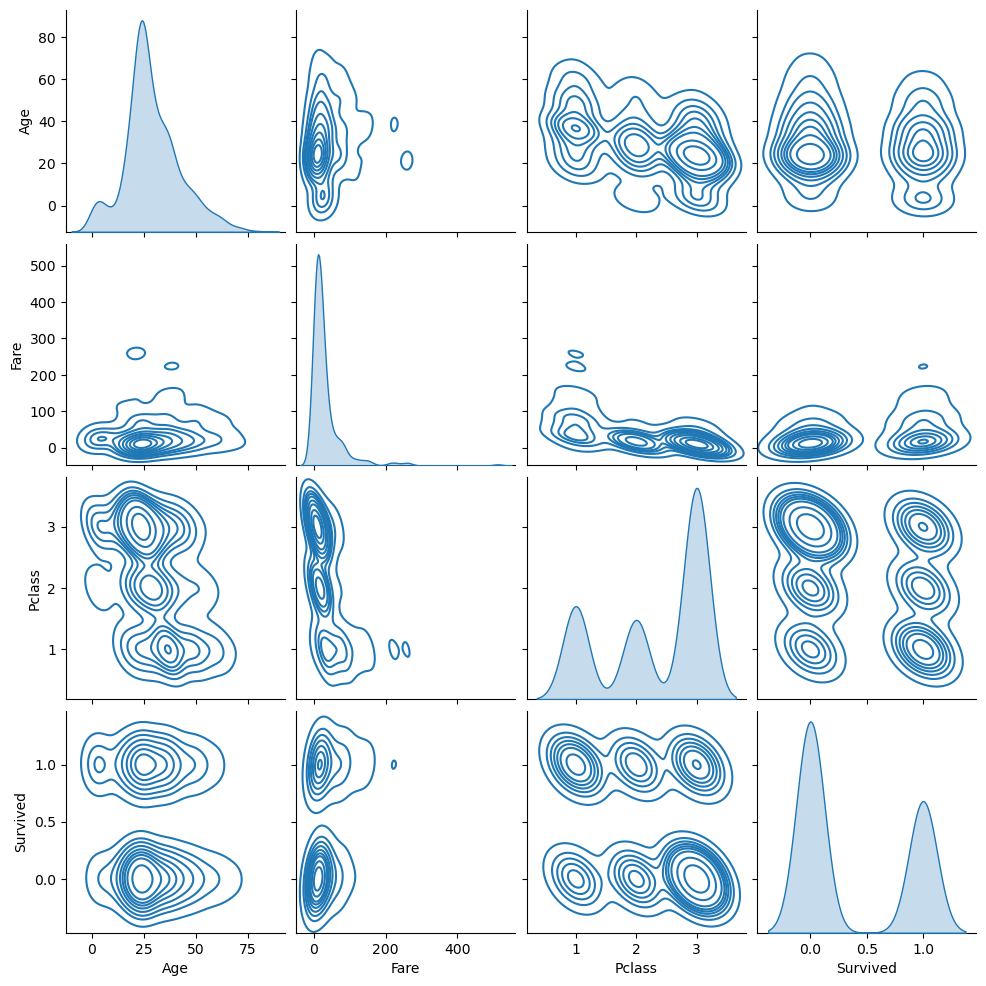

In [28]:
sns.pairplot(data = train , kind = 'kde' , x_vars=['Age', 'Fare', 'Pclass', 'Survived'] ,  y_vars=['Age', 'Fare', 'Pclass', 'Survived'])

## Analyze whether children had higher survival rates

In [29]:
def children(age):
    if age <= 15:
        return "Children"
    else:
        return "Not Children"

<Axes: xlabel='Child', ylabel='Survived'>

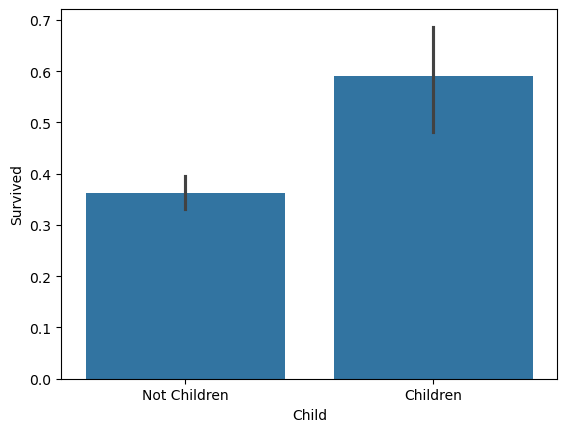

In [30]:
train['Child'] = train['Age'].apply(children)

sns.barplot(data=train, x='Child', y='Survived')

#### This bar plot clearly illustrates that age categorization played a major role in survival. The data shows that "Children" had a survival rate of nearly 60%, compared to just over 35% for "Not Children" (adults). This stark difference serves as direct evidence that younger passengers were given priority access to the lifeboats.

## Observations

* Female passengers had higher survival rates compared to males
* Passengers in first class had better chances of survival
* Fare is positively related to survival, indicating wealthier passengers were prioritized
* Age distribution shows most passengers were between 20–40 years
* Missing values are present in Age and Cabin, which need to be handled carefully


# Conclusion: Key Drivers of Survival on the Titanic

The exploratory data analysis of the Titanic dataset reveals that survival was not random, but heavily influenced by a passenger's demographic and socioeconomic characteristics.

### Gender as the Primary Factor

Gender emerged as the most significant determinant of survival. Female passengers had a survival rate of approximately **74%**, whereas less than **20%** of male passengers survived. This highlights a strong gender-based disparity.

### Impact of Age

Age also played a crucial role. Children, particularly those under the age of five, were prioritized during evacuation. This indicates that younger passengers had a higher likelihood of survival compared to adults.

### "Women and Children First" Policy

The combined influence of gender and age provides strong evidence that the historical **"women and children first"** protocol was actively followed during the disaster.

### Socioeconomic Status (Class & Fare)

Socioeconomic status, represented by **Passenger Class (Pclass)** and **Fare**, was another major factor:

* First-class passengers had significantly higher survival rates compared to third-class passengers.
* Wealthier individuals had better access to lifeboats and safer locations on the ship.

### Class Divide and Embarkation

A clear class divide is observed:

* First-class passengers survived at nearly **three times** the rate of third-class passengers.
* Passengers who embarked from **Cherbourg** showed higher survival rates, likely due to a higher proportion of first-class travelers.
* In contrast, many third-class passengers boarded at **Southampton**, contributing to higher casualties in that group.

### Family Size Influence

Although passengers often traveled with family, variables such as **SibSp** and **Parch** showed weak correlation with survival. This suggests that family size did not significantly impact survival probability.

### Final Insight

Overall, the data indicates that a **young, female, first-class passenger** had the highest probability of survival, while a **young adult male in third class** faced the lowest chances.
